# Clustering on Iris Dataset

## Loading and Preprocessing

In [3]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [4]:
# Load dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [6]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Data after scaling:\n", X_scaled[:5])

Data after scaling:
 [[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


# KMeans Clustering

### K-Means Clustering – Brief Description

K-Means is an unsupervised learning algorithm used to group data into K clusters based on similarity.

🔹 How it works:
Choose K (number of clusters).
Initialize centroids randomly (K points).
Assign data points to the nearest centroid (using distance like Euclidean distance).
Update centroids by computing the mean of all points in each cluster.
Repeat steps 3–4 until the centroids no longer change (convergence).

🔹 Key Idea:

It minimizes the distance between data points and their cluster centroid, making clusters as compact as possible.

🔹 Simple Example:

If K = 3, the algorithm will divide the dataset into 3 groups, where points in the same group are more similar to each other than to those in other groups.

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


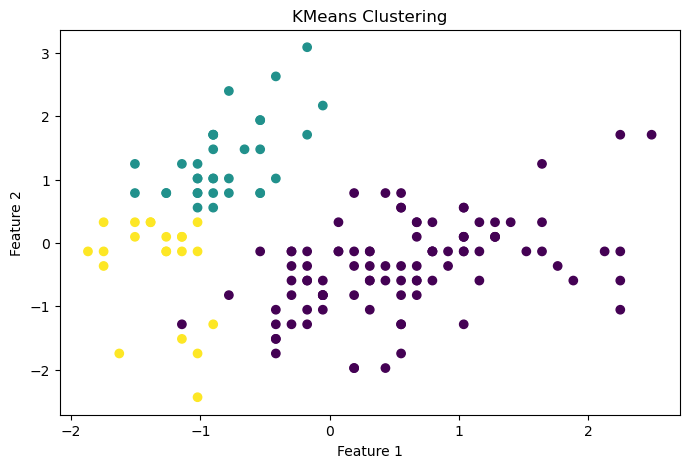

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Add labels to dataframe
df['KMeans_Cluster'] = kmeans_labels

# Visualization (using first 2 features)
plt.figure(figsize=(8,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels)
plt.title("KMeans Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### 🔹 1. Three Distinct Clusters Identified
The algorithm has successfully divided the data into 3 clusters.
This aligns well with the known structure of the Iris dataset (3 species).
### 🔹 2. One Cluster is Well Separated
The cluster on the right side (purple) is clearly separated from the others.
This indicates that this group has distinct feature values → easy for KMeans to identify.
In Iris, this usually corresponds to Setosa (most separable class).
### 🔹 3. Partial Overlap Between Two Clusters
The yellow and teal clusters (left side) show some overlap.
This means:
These groups are less distinguishable
Their feature values are closer together
In Iris, this typically reflects Versicolor and Virginica, which are harder to separate.
### 🔹 4. Compactness of Clusters
Points within each cluster are relatively close to each other, showing good clustering.
KMeans has minimized intra-cluster distance effectively.
### 🔹 5. Shape Limitation of KMeans
Clusters appear spherical/rounded, which is expected.
KMeans assumes clusters are:
Similar in size
Convex in shape
If data had irregular shapes, KMeans might struggle.
### 🔹 6. Feature Influence
Since only 2 features are visualized, some overlap may appear.
Using all 4 features internally helps KMeans perform better than what is visually seen.

# Hierarchical Clustering

### Hierarchical Clustering – Brief Description

Hierarchical clustering is an unsupervised learning algorithm that builds a hierarchy (tree-like structure) of clusters.

🔹 How it works:

There are two main approaches, but the most common is Agglomerative (bottom-up):

Start with each data point as its own cluster.
Find the two closest clusters based on a distance metric.
Merge them into one cluster.
Repeat this process until all points are merged into a single cluster.

🔹 Output:
The result is a dendrogram, a tree diagram showing how clusters are merged at each step.
You can cut the dendrogram at a chosen level to get the desired number of clusters.

🔹 Key Idea:

Clusters are formed based on similarity and linkage criteria (like single, complete, or average linkage), without needing to predefine the number of clusters initially.

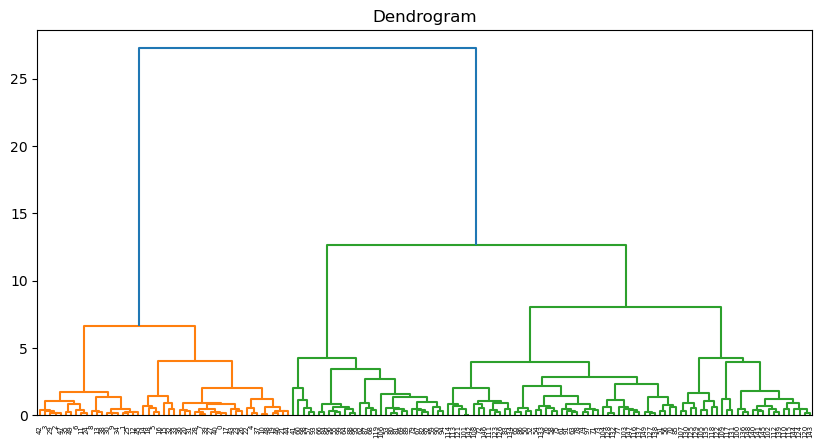

In [8]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Create dendrogram
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

### 🔹 1. Clear Formation of Three Major Clusters
The dendrogram shows three well-defined groups when cut at an appropriate height.
This matches the expected structure of the Iris dataset (3 natural clusters).
### 🔹 2. Large Vertical Gap (Optimal Cut Point)
There is a big jump in linkage distance (around ~12–27 on the y-axis).
This indicates a natural separation between clusters.
Cutting the dendrogram at this height gives optimal clustering.
### 🔹 3. One Cluster is Highly Distinct
The leftmost cluster (orange) merges with others at a much higher distance.
This means:
It is very different from the rest
Likely represents the most separable group (Setosa in Iris)
### 🔹 4. Two Clusters are More Similar
The middle and right clusters (green) merge at lower distances.
This suggests:
These groups are closer in feature space
Harder to distinguish (like Versicolor & Virginica)
### 🔹 5. Hierarchical Structure Insight
Unlike KMeans, this shows how clusters are formed step-by-step.
You can see:
Small clusters forming first
Then merging into larger clusters
### 🔹 6. No Need to Predefine Clusters
You didn’t need to specify “3 clusters” initially.
The dendrogram itself reveals the optimal number of clusters.

In [9]:
# Apply Agglomerative Clustering
hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(X_scaled)

# Add labels
df['HC_Cluster'] = hc_labels

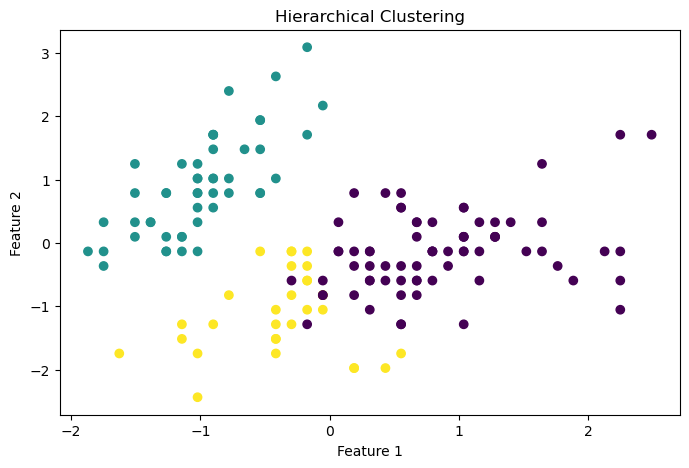

In [10]:
# Visualization
plt.figure(figsize=(8,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=hc_labels)
plt.title("Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### 🔹 1. Three Clusters Clearly Formed
The algorithm has grouped the data into 3 clusters, consistent with the Iris dataset structure.
This confirms the dendrogram’s suggestion of an optimal cluster count.
### 🔹 2. One Cluster is Clearly Separated
The right-side cluster (purple) is well separated from the others.
This indicates a distinct group with unique feature values.
Similar to KMeans, this represents the easiest cluster to identify.
### 🔹 3. Overlap Between Two Clusters
The yellow and teal clusters (left side) show noticeable overlap.
This suggests:
These groups have similar characteristics
Harder to distinguish perfectly
This is expected in Iris (Versicolor & Virginica overlap).
### 🔹 4. More Flexible Cluster Shapes
Compared to KMeans, clusters here are less strictly spherical.
Hierarchical clustering can capture irregular shapes better.
### 🔹 5. Better Local Grouping
Points that are close together tend to form tight sub-clusters first, then merge.
This results in more natural grouping compared to KMeans in some areas.
### 🔹 6. Slight Differences from KMeans
Some points may be assigned differently compared to KMeans.
This happens because:
KMeans → centroid-based
Hierarchical → distance/linkage-based

# Conclusion
- Both KMeans and Hierarchical clustering successfully grouped the Iris dataset into 3 clusters.
KMeans is faster and efficient for large datasets.
Hierarchical clustering provides better visualization (dendrogram) and insight into cluster relationships.